In [ ]:
from featuregraph.datasets import arc_agi
import numpy as np
import matplotlib.pyplot as plt

df_load_data = arc_agi("00576224", split="training")

pair_type = 'train'
pair_index = 0

def reconstruct_grid(df, pair_type, pair_index, grid_role):
    mask = (df['pair_type'] == pair_type) & (df['pair_index'] == pair_index) & (df['grid_role'] == grid_role)
    cells = df[mask]

    return cells.pivot(
        index="row",
        columns="column",
        values="color",
    ).to_numpy()


input = reconstruct_grid(df_load_data, pair_type, pair_index, 'input')
output = reconstruct_grid(df_load_data, pair_type, pair_index, 'output')

input_height, input_width = input.shape
output_height, output_width = output.shape

row, column = np.indices(output.shape)
output_cells = np.array([row.ravel(), column.ravel(), output.ravel()]).T
block_coordinates = np.array([row.ravel() // input_height, column.ravel() // input_width, row.ravel() % input_height, column.ravel() % input_width]).T
view = np.concatenate((output_cells, block_coordinates), axis=1)

In [ ]:
view

array([[0, 0, 7, 0, 0, 0, 0],
       [0, 1, 9, 0, 0, 0, 1],
       [0, 2, 7, 0, 1, 0, 0],
       [0, 3, 9, 0, 1, 0, 1],
       [0, 4, 7, 0, 2, 0, 0],
       [0, 5, 9, 0, 2, 0, 1],
       [1, 0, 4, 0, 0, 1, 0],
       [1, 1, 3, 0, 0, 1, 1],
       [1, 2, 4, 0, 1, 1, 0],
       [1, 3, 3, 0, 1, 1, 1],
       [1, 4, 4, 0, 2, 1, 0],
       [1, 5, 3, 0, 2, 1, 1],
       [2, 0, 9, 1, 0, 0, 0],
       [2, 1, 7, 1, 0, 0, 1],
       [2, 2, 9, 1, 1, 0, 0],
       [2, 3, 7, 1, 1, 0, 1],
       [2, 4, 9, 1, 2, 0, 0],
       [2, 5, 7, 1, 2, 0, 1],
       [3, 0, 3, 1, 0, 1, 0],
       [3, 1, 4, 1, 0, 1, 1],
       [3, 2, 3, 1, 1, 1, 0],
       [3, 3, 4, 1, 1, 1, 1],
       [3, 4, 3, 1, 2, 1, 0],
       [3, 5, 4, 1, 2, 1, 1],
       [4, 0, 7, 2, 0, 0, 0],
       [4, 1, 9, 2, 0, 0, 1],
       [4, 2, 7, 2, 1, 0, 0],
       [4, 3, 9, 2, 1, 0, 1],
       [4, 4, 7, 2, 2, 0, 0],
       [4, 5, 9, 2, 2, 0, 1],
       [5, 0, 4, 2, 0, 1, 0],
       [5, 1, 3, 2, 0, 1, 1],
       [5, 2, 4, 2, 1, 1, 0],
       [5,

NameError: name 'manual_output' is not defined

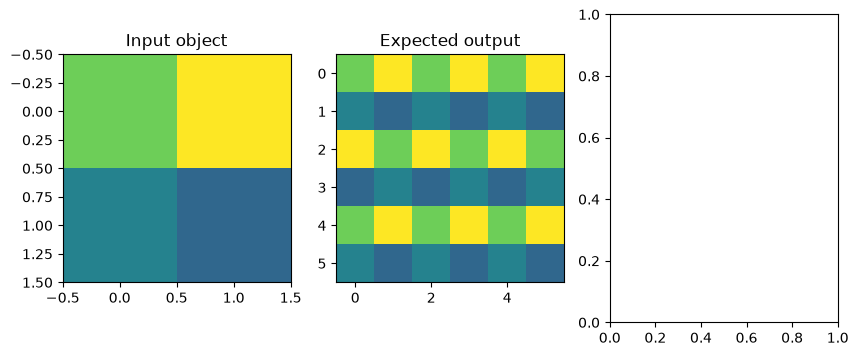

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].imshow(input, vmin=0, vmax=9)
axes[0].set_title("Input object")

axes[1].imshow(output, vmin=0, vmax=9)
axes[1].set_title("Expected output")

axes[2].imshow(manual_output, vmin=0, vmax=9)
axes[2].set_title("Reconstructed output")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()